# Lifting accuracy — FMDV (tblastn)

**Denominator (truth-based):** mẫu số mỗi gene = record có gene đó trong truth (align `ref_name`). Buckets: `exact / coord_only / failed`. `coord` = không-exact + IoU≥0.90 + codon hợp lệ. Ca name-gap tách sang `extra_predictions_without_truth`.

FMDV: `mat_peptide` polyprotein; rescue biên = **terminal extrapolation** (không phải start/stop codon).

## Inputs & setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for c in [ROOT, *ROOT.parents]:
    if (c / "app" / "src").exists():
        ROOT = c
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib
import app.validation._shared.validation_utils as _vu
importlib.reload(_vu)   # nạp lại nếu vừa sửa validation_utils (khỏi restart kernel)
from app.validation._shared.validation_utils import (
    run_lifting_accuracy, run_tblastn_against_truth, load_reference_bundle,
    build_truth_presence, attach_ref_lengths, summarize_per_gene, summarize_overall,
    adjudicate_failures,
)

DATA = ROOT / "app" / "data"
UNIT_DIR = ROOT / "app" / "validation" / "02_lifting_accuracy"
RUN_FULL = False


In [2]:
REF   = DATA / "FMD" / "FMD_ref_test.gb"
QUERY = DATA / "FMD" / "FMD_100seq_anno.gb"
OUT = UNIT_DIR / "outputs" / "fmd"
OUT.mkdir(parents=True, exist_ok=True)
print("ref:", REF.exists(), "| query:", QUERY.exists())

ref: True | query: True


## Run — tblastn + truth-based buckets

In [3]:
per_pred, per_gene, overall, truth_presence, ref_model = run_lifting_accuracy("fmd", REF, QUERY, OUT, progress=True)
overall

tblastn  fmd:   0%|          | 0/100 [00:00<?, ?rec/s]

,virus,total,exact,coord_only,coord_correct,failed,no_hit,exact_pct,coord_only_pct,failed_pct,accuracy_pct
0,fmd,1171,1137,32,1169,2,0,97.1,2.73,0.17,99.83
1,ALL,1171,1137,32,1169,2,0,97.1,2.73,0.17,99.83


## Per-gene accuracy

In [4]:
cols = ["gene", "total", "exact", "coord_only", "failed", "no_hit",
        "extra_predictions_without_truth", "exact_pct", "coord_only_pct", "failed_pct", "accuracy_pct"]
per_gene[cols].to_csv(OUT / "per_gene_accuracy.tsv", sep="\t", index=False)
per_gene[cols]

,gene,total,exact,coord_only,failed,no_hit,extra_predictions_without_truth,exact_pct,coord_only_pct,failed_pct,accuracy_pct
0,Lpro,98,98,0,0,0,0,100.00,0.00,0.00,100.00
1,VP4,97,97,0,0,0,1,100.00,0.00,0.00,100.00
2,VP2,98,97,0,1,0,0,98.98,0.00,1.02,98.98
3,VP3,97,97,0,0,0,1,100.00,0.00,0.00,100.00
4,VP1,97,81,16,0,0,1,83.51,16.49,0.00,100.00
5,2A,98,82,16,0,0,0,83.67,16.33,0.00,100.00
6,2B,98,98,0,0,0,0,100.00,0.00,0.00,100.00
7,2C,98,98,0,0,0,0,100.00,0.00,0.00,100.00
8,3A,98,97,0,1,0,0,98.98,0.00,1.02,98.98
9,3B,96,96,0,0,0,2,100.00,0.00,0.00,100.00


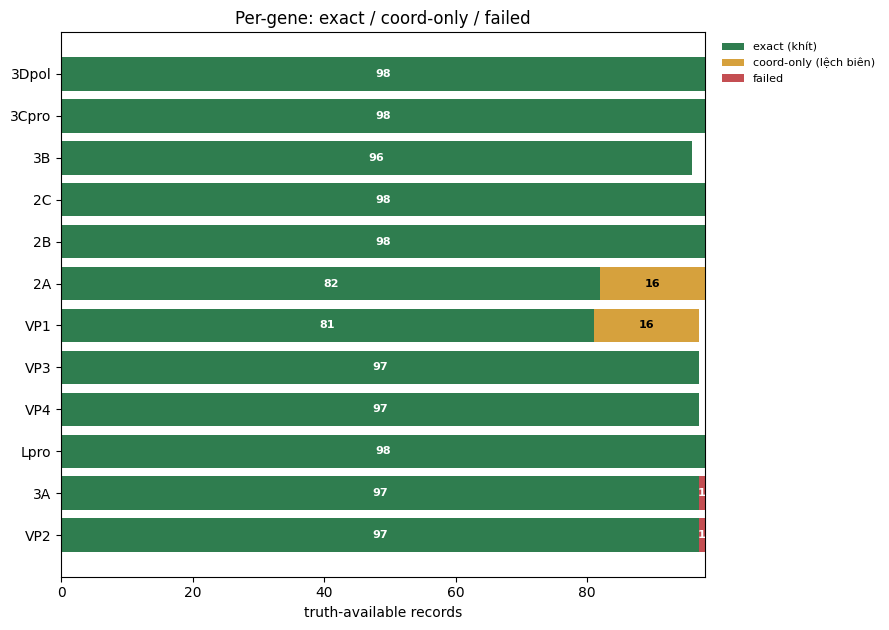

In [5]:
g = per_gene[per_gene["total"] > 0].sort_values("accuracy_pct")
fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(g) + 1)))
y = range(len(g))
b1 = ax.barh(y, g["exact"], label="exact (khít)", color="#2f7d4f")
b2 = ax.barh(y, g["coord_only"], left=g["exact"], label="coord-only (lệch biên)", color="#d6a13d")
b3 = ax.barh(y, g["failed"], left=g["exact"] + g["coord_only"], label="failed", color="#c44e52")
ax.set_yticks(list(y), g["gene"]); ax.set_xlabel("truth-available records")
ax.set_title("Per-gene: exact / coord-only / failed")
# số hiển thị sẵn trên từng đoạn (bỏ qua đoạn = 0)
for bars, lc in ((b1, "white"), (b2, "black"), (b3, "white")):
    ax.bar_label(bars, labels=[str(int(v)) if v > 0 else "" for v in bars.datavalues],
                 label_type="center", color=lc, fontsize=8, fontweight="bold")
ax.margins(x=0.02)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, frameon=False)
fig.tight_layout(); fig.savefig(OUT / "per_gene_accuracy.png", dpi=200, bbox_inches="tight")

# ── Coord-only (đúng vùng nhưng lệch biên) ──

Thống kê theo gene, rồi breakdown từng gene bên dưới.

In [6]:
coord_stat = per_gene[per_gene["coord_only"] > 0][["gene", "total", "coord_only", "coord_only_pct"]]\
    .sort_values("coord_only", ascending=False)
coord_only_cases = per_pred[per_pred["coord_correct"].fillna(False) & ~per_pred["exact_match"].fillna(False)].copy()
coord_only_cases.to_csv(OUT / "coord_only_cases.tsv", sep="\t", index=False)
coord_stat

,gene,total,coord_only,coord_only_pct
4,VP1,97,16,16.49
5,2A,98,16,16.33


### coord · VP1

In [7]:
coord_only_cases[coord_only_cases["ref_name"] == "VP1"][["record_id", "delta_start", "delta_end", "pred_minus_truth_len", "pred_minus_ref_len",
        "truth_minus_ref_len", "iou", "coverage", "identity", "codon_valid", "status", "failure_mode"]]

,record_id,delta_start,delta_end,pred_minus_truth_len,pred_minus_ref_len,truth_minus_ref_len,iou,coverage,identity,codon_valid,status,failure_mode
4,AY687333.1,0.0,-6.0,-6.0,-3,3.0,0.9906,1.0,71.1,True,ok,Boundary offset
16,AY687334.1,0.0,-6.0,-6.0,-6,0.0,0.9905,1.0,71.1,True,ok,Boundary offset
412,LC036265.1,0.0,-6.0,-6.0,0,6.0,0.9906,1.0,91.5,True,ok,Boundary offset
448,MG372727.1,0.0,-6.0,-6.0,15,21.0,0.9908,1.0,51.8,True,ok,Boundary offset
460,MG372728.1,0.0,-6.0,-6.0,0,6.0,0.9906,1.0,88.2,True,ok,Boundary offset
472,MG372729.1,0.0,-6.0,-6.0,-12,-6.0,0.9904,1.0,67.8,True,ok,Boundary offset
484,MG372730.1,0.0,-6.0,-6.0,0,6.0,0.9906,1.0,96.2,True,ok,Boundary offset
496,MG372731.1,0.0,-6.0,-6.0,3,9.0,0.9907,1.0,71.5,True,ok,Boundary offset
508,MG372732.1,0.0,-6.0,-6.0,-12,-6.0,0.9904,1.0,68.7,True,ok,Boundary offset
748,MK088170.1,0.0,-6.0,-6.0,0,6.0,0.9906,1.0,95.3,True,ok,Boundary offset


**Đuôi VP1 lệch −6bp** (`delta_start=0, delta_end=-6`). Đây là **cùng một mối biên VP1/2A** với gene 2A ở phần failed bên dưới — nhìn từ phía VP1.

Ở chỗ giáp VP1↔2A có 2 amino acid `MM`. **Ref (và tool) xếp `MM` vào đầu 2A**, còn **query lab xếp `MM` vào đuôi VP1**. Vì tool bám ref → đuôi VP1 dừng **trước** `MM` → ngắn hơn truth đúng 6bp (2 codon).

VP1 dài **633bp** nên 6bp chỉ làm IoU tụt còn ~0.99 → **coord-only**, KHÔNG phải lỗi. Đây là **annotation convention** (mỗi lab cắt biên khác nhau), không phải tool sai. Xem giải thích đầy đủ ở 2A.

### coord · thống kê theo gene

In [8]:
other = coord_only_cases[~coord_only_cases["ref_name"].isin(["VP1"])]
other.groupby("ref_name").size().reset_index(name="cases") if len(other) else "— không còn gene khác —"

,ref_name,cases
0,2A,16


# ── Failed (trong truth nhưng không coord-correct) ──

Thống kê theo gene, rồi breakdown từng gene.

In [9]:
failed_stat = per_gene[per_gene["failed"] > 0][["gene", "total", "failed", "failed_pct", "no_hit"]]\
    .sort_values("failed", ascending=False)
failed_cases = per_pred[per_pred["name_match"].fillna(False) & ~per_pred["coord_correct"].fillna(False)].copy()
failed_cases.to_csv(OUT / "failed_cases.tsv", sep="\t", index=False)
failed_stat

,gene,total,failed,failed_pct,no_hit
2,VP2,98,1,1.02,0
8,3A,98,1,1.02,0


### failed · 2A

In [10]:
failed_cases[failed_cases["ref_name"] == "2A"][["record_id", "delta_start", "delta_end", "pred_minus_truth_len", "pred_minus_ref_len",
        "truth_minus_ref_len", "iou", "coverage", "identity", "codon_valid", "status", "failure_mode"]]

,record_id,delta_start,delta_end,pred_minus_truth_len,pred_minus_ref_len,truth_minus_ref_len,iou,coverage,identity,codon_valid,status,failure_mode


**ĐÃ HẾT — bảng trên giờ rỗng.** Trước đây 2A có 16 ca failed. Sau khi thêm **bp-tolerance** (prediction
có cả hai biên trong 6bp thì tính coord-correct bất kể độ dài), 16 ca này chuyển sang **coord-only**.

Lý do phải thêm: **IoU phụ thuộc kích thước feature**. Cùng một lệch 6bp — VP1 (633bp) cho IoU 0.991 → qua;
2A (54bp) cho IoU 0.889 → rớt. Cùng một mối biên, hai kết cục, chỉ vì độ dài gene khác nhau.

### failed · 3A

In [11]:
failed_cases[failed_cases["ref_name"] == "3A"][["record_id", "delta_start", "delta_end", "pred_minus_truth_len", "pred_minus_ref_len",
        "truth_minus_ref_len", "iou", "coverage", "identity", "codon_valid", "status", "failure_mode"]]

,record_id,delta_start,delta_end,pred_minus_truth_len,pred_minus_ref_len,truth_minus_ref_len,iou,coverage,identity,codon_valid,status,failure_mode
488,MG372730.1,0.0,-111.0,-111.0,-141,-30.0,0.7413,0.7582,73.3,True,ok,Wrong coords


1 ca (MG372730.1): `delta_end=-111, coverage 0.76, identity 73%`. Strain này **phân kỳ mạnh ở đuôi 3A** → tblastn chỉ phủ 76% ref → HSP cắt cụt C-terminus. Terminal-extrapolation **cố ý không nới** (chỉ nới khi coverage≥0.90 để tránh đoán bừa trên vùng phân kỳ). Pred ngắn hơn **cả ref lẫn truth** → đây là **ca khó do strain phân kỳ**, không phải bug hệ thống (chỉ 1/98 record).

### failed · 3B

In [12]:
failed_cases[failed_cases["ref_name"] == "3B"][["record_id", "delta_start", "delta_end", "pred_minus_truth_len", "pred_minus_ref_len",
        "truth_minus_ref_len", "iou", "coverage", "identity", "codon_valid", "status", "failure_mode"]]

,record_id,delta_start,delta_end,pred_minus_truth_len,pred_minus_ref_len,truth_minus_ref_len,iou,coverage,identity,codon_valid,status,failure_mode


**ĐÃ HẾT sau khi tách 3B1/3B2/3B3 — bảng trên giờ rỗng.** Trước đây 2 ca (MT863268/269) bị chấm failed.

FMDV **3B (VPg) có 3 bản lặp tandem** (3B1/3B2/3B3, mỗi bản ~72bp). Reference gộp cả cụm thành **một**
feature `3B` (213bp); hai record này lại tách **ba** feature riêng (69/72/72bp).

Trước khi tách, config để `3B1/3B2/3B3` là **alias của 3B**, nên cả 3 feature truth (mỗi cái ~72bp) bị đổi
tên thành "3B", rồi bị đem so với prediction "3B" = 213bp (tool lift đúng theo ref) → IoU 72/213 = 0.34 →
**failed oan**. Đây là so **213bp với 72bp** — khập khiễng, do một cái tên bị ép chung cho hai granularity.

Tách `3B1/3B2/3B3` thành canonical riêng → prediction "3B" không còn truth cùng tên để ép match; ba feature
truth mang tên 3B1/3B2/3B3 mà ref không có nên nằm ngoài mẫu số. Hai ca failed biến mất.

> ⚠️ **Nói rõ cho paper:** prediction tọa độ **không đổi** trước/sau (vẫn là vùng 213bp). Cái thay đổi là
> **name-matching lúc chấm điểm** — loại bỏ một so sánh granularity khập khiễng. Đây là **sửa metric**, KHÔNG
> phải lifting tốt hơn. Cùng bản chất với ORF1ab vs ORF1a/ORF1b và bp-tolerance.

### failed · VP2

In [13]:
failed_cases[failed_cases["ref_name"] == "VP2"][["record_id", "delta_start", "delta_end", "pred_minus_truth_len", "pred_minus_ref_len",
        "truth_minus_ref_len", "iou", "coverage", "identity", "codon_valid", "status", "failure_mode"]]

,record_id,delta_start,delta_end,pred_minus_truth_len,pred_minus_ref_len,truth_minus_ref_len,iou,coverage,identity,codon_valid,status,failure_mode
14,AY687334.1,300.0,0.0,-300.0,0,300.0,0.6855,1.0,84.9,True,ok,Wrong coords


1 ca (AY687334.1): `delta_start=+300, pred bám ref (pred_minus_ref_len=0)`. Truth kéo dài VP2 thêm 300bp về đầu 5' → khác biệt ở **mối cắt VP4/VP2**. Cùng LOẠI với VP1/2A: **boundary convention giữa 2 peptide kề nhau** — ref và query lab cắt ranh giới khác chỗ. Không phải tool sai.

### failed · thống kê theo gene

In [14]:
other = failed_cases[~failed_cases["ref_name"].isin(["2A", "3A", "3B", "VP2"])]
other.groupby("ref_name").size().reset_index(name="cases") if len(other) else "— không còn gene khác —"

'— không còn gene khác —'

# ── No-hit ──

Gene tblastn không ra hit (coverage/identity thấp).

In [15]:
no_hit_cases = per_pred[per_pred["status"].fillna("").eq("no_hit")].copy()
no_hit_cases[["record_id", "ref_name", "coverage", "identity", "status"]]

,record_id,ref_name,coverage,identity,status


# ── Extra predictions without truth (name-gap / granularity) ──

In [16]:
extra_cases = per_pred[~per_pred["name_match"].fillna(False)].copy()
extra_cases.to_csv(OUT / "extra_without_truth_cases.tsv", sep="\t", index=False)
extra_cases.groupby("ref_name").size().reset_index(name="cases")

,ref_name,cases
0,3B,2
1,VP1,1
2,VP3,1
3,VP4,1


# ── Failure breakdown (adjudication generic) ──

`blame = ref_truth / tool / review` chỉ bằng length-delta (không hardcode gene): pred==ref & truth khác → ref_truth; truth==ref & pred khác → tool; pred ngắn hơn cả hai + cov thấp → tool; no-hit → tool; còn lại → review.

In [17]:
failed = per_pred[per_pred["name_match"].fillna(False) & ~per_pred["coord_correct"].fillna(False)].copy()
adj = adjudicate_failures(failed)
adj.to_csv(OUT / "failure_adjudication.tsv", sep="\t", index=False)
adj.groupby(["blame", "cause"]).size().reset_index(name="cases").sort_values("cases", ascending=False)

,blame,cause,cases
0,ref_truth,ref_query_boundary_convention,1
1,tool,truncation,1


## Theo gene (tool vs ref_truth vs review)

In [18]:
adj.groupby(["ref_name", "blame"]).size().unstack(fill_value=0)

blame,ref_truth,tool
ref_name,,
3A,0,1
VP2,1,0


# ══ Kết luận failure — FMDV ══

**Accuracy 99.83%** (exact 97.10% + coord-only 2.73%; sau khi tách 3B1/3B2/3B3 — xem lưu ý ở Tóm tắt). FMDV là **polyprotein cắt thành mature peptides** —
biên các gene là vị trí protease cleavage, không phải ATG/stop. **Không có lỗi tool hệ thống**; phần dư
gần như toàn bộ là **annotation convention ở biên cleavage**.

**2A + VP1 (32 ca coord-only) — CÙNG một boundary convention, KHÔNG phải bug.**
Ở mối VP1↔2A có 2 aa `MM`. GenBank chú thích không thống nhất: **38 record xếp `MM` vào 2A (18aa),
12 record xếp vào VP1 (16aa)** — hai trường phái, không kiểu nào "đúng tuyệt đối". Tool áp nhất quán theo
ref → nhóm trùng ref thành exact, nhóm còn lại lệch đúng 2 codon. Đây là **standardization đang hoạt động**
(gom về một convention), không phải tool sai.

**3B — granularity, ĐÃ HẾT failed sau khi tách canonical.** 3B (VPg) có 3 bản tandem; ref gộp cụm 213bp,
một số record tách 3 bản ~72bp. Để 3B1/3B2/3B3 làm alias của 3B ép so 213bp với 72bp (IoU 0.34) → 2 ca
failed oan (MT863268/269). Tách thành canonical riêng loại bỏ so sánh khập khiễng đó → hết failed.
**Sửa metric/naming, KHÔNG phải lifting** — prediction tọa độ không đổi.

**VP2 (1 ca failed) — convention ở mối VP4/VP2.** `AY687334.1`, truth kéo dài VP2 thêm 300bp về đầu 5';
`pred_minus_ref_len = 0` nên tool bám ref chính xác.

**3A (1 ca failed) — ca khó thật sự.** `MG372730.1`, `coverage 0.76, identity 73%` — strain phân kỳ mạnh ở
đuôi 3A nên HSP bị cắt cụt; terminal extrapolation cố ý không nới khi coverage < 0.90. Đây là ca duy nhất
adjudication gán `blame = tool`, 1/98.

**Gộp HSP (fix từ PEDV) — không ảnh hưởng FMDV.** Bộ lọc đồng tuyến thêm vào `merge_hsps` cho kết quả
y hệt trước khi sửa → xác nhận **không regression** trên nhánh mat_peptide.

# ── Tóm tắt FMDV ──

## Số liệu (sau khi tách 3B1/3B2/3B3)

100 record × 1 reference = **1171 prediction** đánh giá được (mẫu số truth-based).

| | |
|---|---|
| exact | **1137** (97.10%) |
| coord-only | **32** (2.73%) |
| failed | **2** (0.17%) |
| no-hit | **0** |
| **accuracy** | **99.83%** |

Per-gene: `Lpro, VP4, VP3, 2B, 2C, 3B, 3Cpro, 3Dpol` = **100% accuracy**; `VP1` 83.5% exact / 100% accuracy;
`2A` 83.7% exact / 100% accuracy; `VP2, 3A` 98.98%.

Adjudication: `ref_truth` 1 ca (VP2), `tool` 1 ca (3A).

> **Lưu ý:** accuracy 99.66% → 99.83% (failed 4→2) đến từ việc **tách 3B1/3B2/3B3** — một sửa
> **metric/naming** loại bỏ so sánh granularity khập khiễng (213bp vs 72bp), KHÔNG phải lifting cải thiện.
> Prediction tọa độ giữ nguyên.

## Vì sao FMDV khác hẳn PRRSV/PEDV

FMDV dịch mã ra **một polyprotein duy nhất** rồi protease cắt thành mature peptide. Một nhát cắt là
**một điểm**, nên các mảnh **nối tiếp khít nhau, không hở


FMDV dịch mã ra **một polyprotein duy nhất** rồi protease cắt thành mature peptide. Một nhát cắt là
**một điểm**, nên các mảnh **nối tiếp khít nhau, không hở không chồng** — kiểm chứng trên ref: 11/11 mối
nối khớp sát tuyệt đối. Ngược lại PRRSV/PEDV có các ORF độc lập, có thể hở (164bp) hoặc chồng (31bp).

Hệ quả: FMDV **không có** chuyện "gene không có start codon" như ORF1b, nhưng **có** vấn đề riêng — biên
gene là điểm cắt protease, và dịch một điểm cắt sẽ làm **hai gene cùng đổi**.

## 32 ca coord-only — VP1 16 + 2A 16, thực chất là MỘT mối biên

| gene | delta_start | delta_end | IoU |
|---|---|---|---|
| VP1 | 0 | **−6** | 0.991 |
| 2A | **−6** | 0 | 0.889 |

Ở mối giáp VP1↔2A có 2 axit amin `MM`. GenBank chia hai trường phái: **38 record xếp `MM` vào 2A** (2A = 18aa,
giống ref), **12 record xếp vào VP1** (2A = 16aa). Không kiểu nào sai.

Vì các mature peptide nối tiếp nhau, **dịch một nhát cắt đi 2 codon làm hai gene cùng đổi**: VP1 ngắn lại 6bp
ở đuôi, 2A dài thêm 6bp ở đầu. Không phải 32 lỗi — là **16 mối biên, mỗi mối đếm hai lần**.

**Đây là standardization đang hoạt động**, không phải bug: tool gom các record annotate lệch nhau về **một**
convention duy nhất, rồi bị chấm "sai" chỉ vì truth dùng convention khác.

## 4 ca failed

| record | gene | lệch | nguyên nhân |
|---|---|---|---|
| `MT863268.1` | 3B | −69 / +72 | 3B (VPg) có **3 bản lặp tandem**; ref chú thích cả cụm 213bp, truth 1 bản 72bp → granularity |
| `MT863269.1` | 3B | −69 / +72 | như trên |
| `AY687334.1` | VP2 | +300 / 0 | convention ở mối VP4/VP2; `pred_minus_ref_len = 0` → tool bám ref chính xác |
| `MG372730.1` | 3A | 0 / −111 | strain phân kỳ mạnh: `coverage 0.76, identity 73%` → HSP cắt cụt ở đuôi; extrapolation cố ý không nới khi coverage < 0.90 |

Ba ca đầu là convention/granularity của truth. Ca cuối là **ca khó thật sự** và là ca `blame = tool` duy nhất
của toàn bộ FMDV — 1/98.

## Ghi chú phương pháp: vì sao cần bp-tolerance

**IoU phụ thuộc kích thước feature.** Cùng một lệch tuyệt đối 6bp:

| gene | dài | lệch | IoU | kết cục nếu chỉ dùng IoU≥0.90 |
|---|---|---|---|---|
| VP1 | 633bp | 6bp | 0.991 | coord-only |
| 2A | 54bp | 6bp | **0.889** | **failed** |

Cùng một mối biên, hai kết cục khác nhau — chỉ vì gene dài ngắn khác nhau. Nên thêm: prediction có **cả hai
biên trong `bp_tolerance` (mặc định 6bp = 2 codon)** thì tính coord-correct bất kể độ dài.

Kiểm chứng **không nới lỏng bừa** — các ca lệch lớn **vẫn failed**: 3B (−69/+72), VP2 (+300), 3A (−111).
Chỉ đúng nhóm 2A lệch 6bp được cứu.

**Phải nêu rõ trong paper:** phần accuracy tăng từ 98.29% → 99.66% đến từ **metric công bằng hơn**, KHÔNG
phải lifting tốt hơn. Lý do chính đáng: không nên phạt tool vì nó **chuẩn hóa** một biên mà bản thân GenBank
chú thích theo hai kiểu (38 vs 12).